# Multimodal (audio-visual) analysis
> This script is running for experiment with auditory and visual (objects) trials.

In [1]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size


dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice'  : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)

from multimodal_functions import (
    get_condition_distribution,
    get_scatter_plot_modalities,
    get_visual_performance_summary, 
    plot_visual_performance_per_object,
    get_multimodal_performance_summary, 
    plot_multimodal_performance_per_object,
    get_auditory_performance_summary,
    plot_auditory_performance_per_object,
    get_linePlot_per_modality_across_sessions,
    calculate_response_type
)

[2026-06-19 09:45:59,387][INFO]: DataJoint 0.14.6 connected to eflab@database.eflab.org:3306


In [2]:
# complete the key
animal_id = 299
from_session = 593
to_session = 615

# define the difficulty level
# one difficulty: [2] or multiple difficulties: [1,2,3]
difficulty = [1,2]

# exclude sessions from plotting
# manual_exclusion_sessions = list(range(180, 280)) + [318,320,322]
manual_exclusion_sessions = []

## Distribution of each condition across sessions

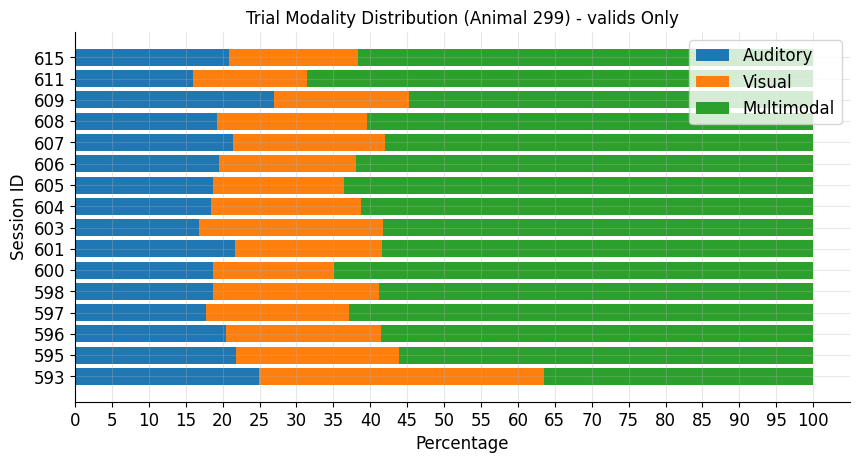

In [3]:
get_condition_distribution(animal_id, from_session, to_session, stim, exp, manual_exclusion_sessions, difficulty)

## Rewards, Punish and Aborts across sessions

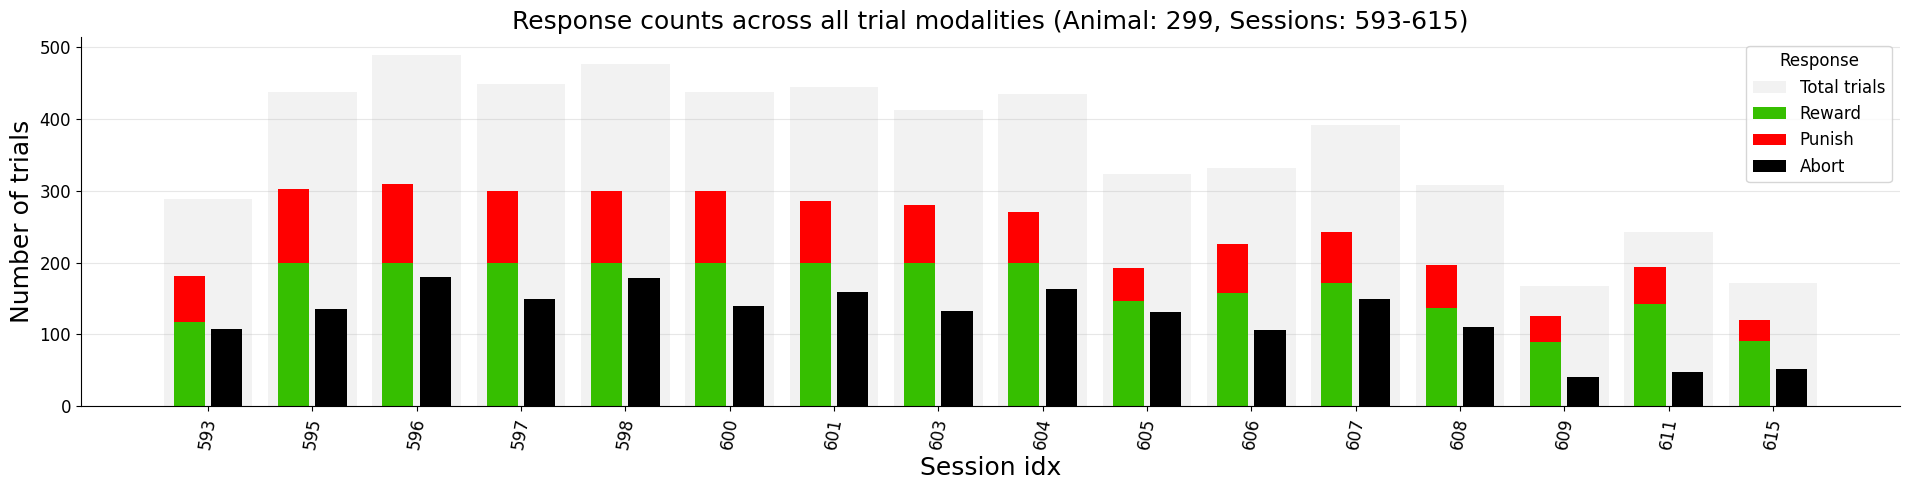

In [ ]:
calculate_response_type(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty,)

## Scatter plot beetween modalites across sessions

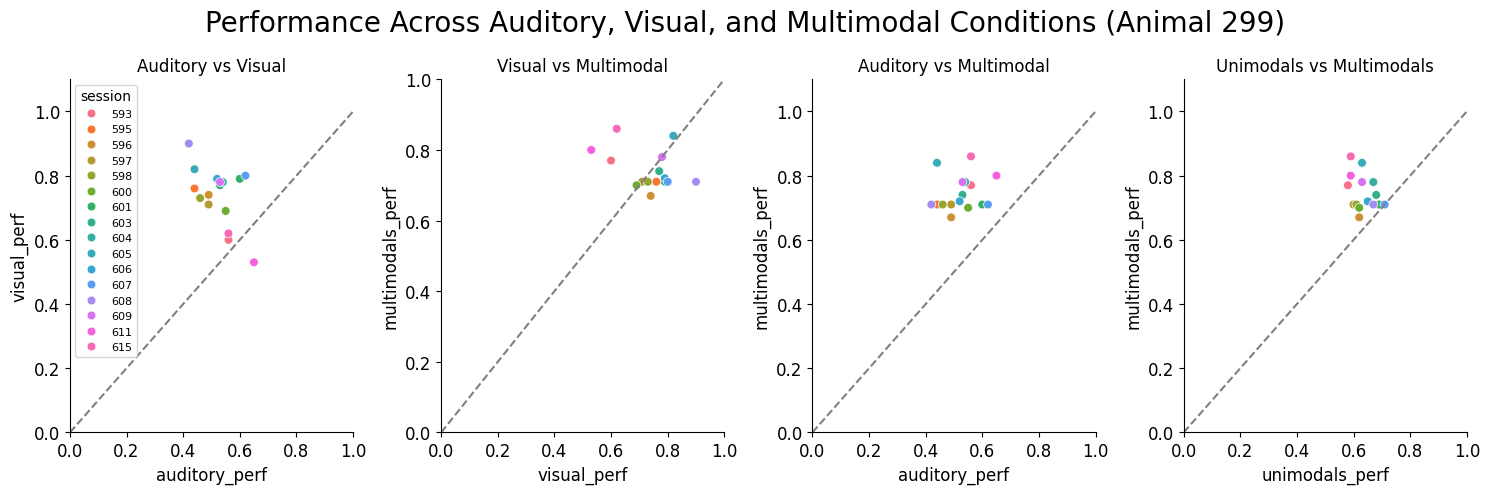

Skipped sessions (missing one or more modalities): []


,session,auditory_perf,visual_perf,multi_perf,uni_perf
0,593,0.56,0.60,0.77,0.58
1,595,0.44,0.76,0.71,0.60
2,596,0.49,0.74,0.67,0.62
3,597,0.49,0.71,0.71,0.60
4,598,0.46,0.73,0.71,0.61
5,600,0.55,0.69,0.70,0.62
6,601,0.60,0.79,0.71,0.69
7,603,0.53,0.77,0.74,0.68
8,604,0.54,0.78,0.78,0.67
9,605,0.44,0.82,0.84,0.63


In [5]:
get_scatter_plot_modalities(animal_id,from_session,to_session,stim, exp,manual_exclusion_sessions,difficulty)

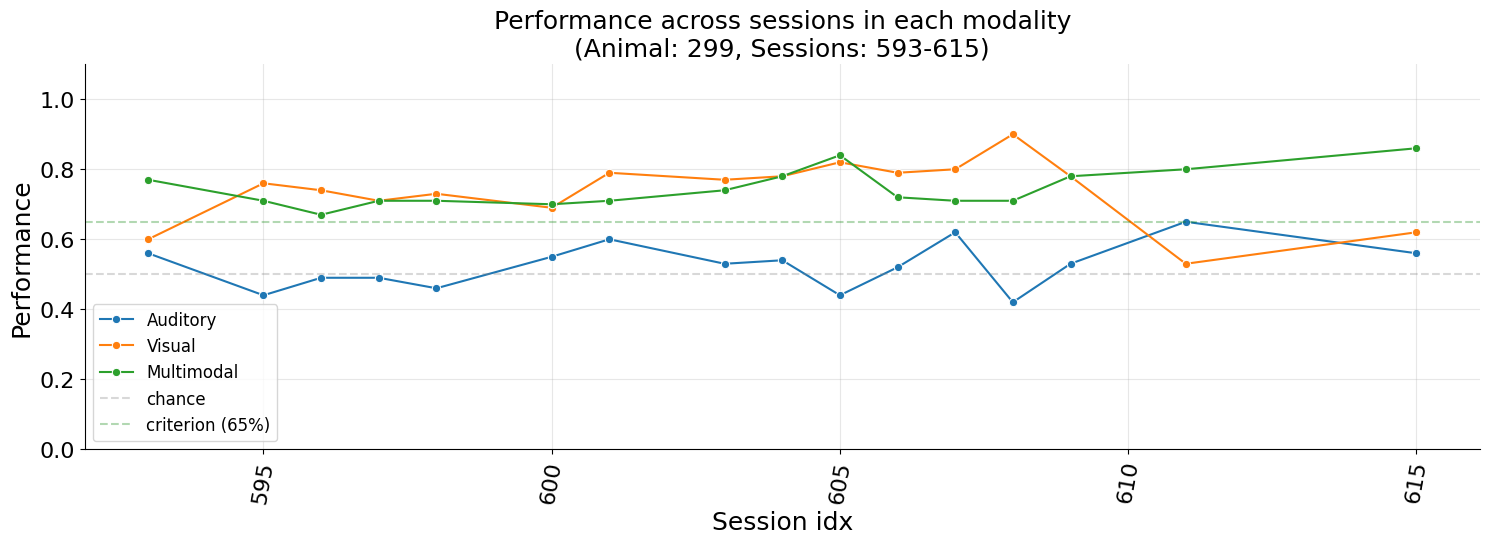

In [6]:
get_linePlot_per_modality_across_sessions(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty,criterion=0.65)

## Performance per object id in each modality across sessions

In [7]:
# Define the key (dict) for unimodal-visual, unimodal-auditory and multimodal trials
# Parameters: animal_id (int), session (int) as a range (from_session, to_session), 
# difficulty level (either one difficulty [1] or multiple [1,2]), object_ids (list), excluded_sessions (list)
# required parameters: animal_id, sessions, difficulties
# defaulted object_ids parameters: [211,212,213,214,215,216,217,218,219]
key = {
    'animal_id': animal_id,
    'sessions': (from_session, to_session), 
    'difficulties': difficulty, 
    'stim': stim,
    'exp': exp,
    'excluded_sessions': manual_exclusion_sessions
}

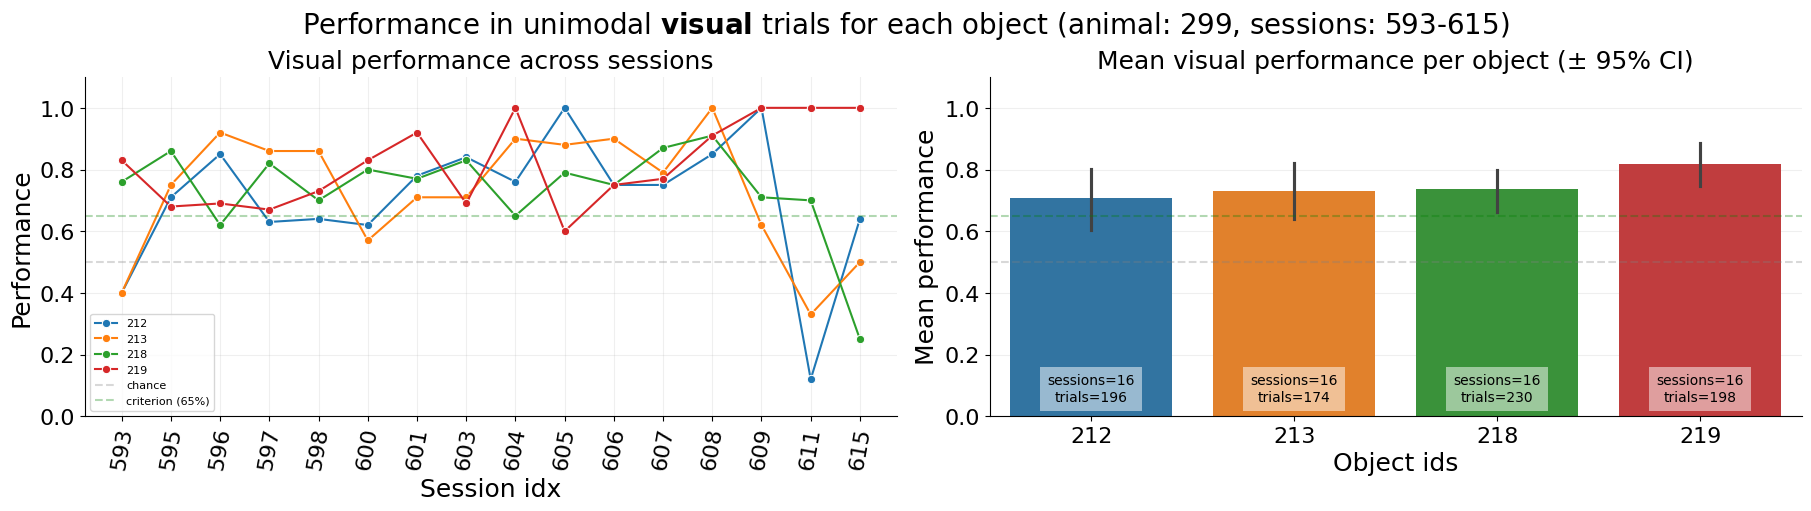

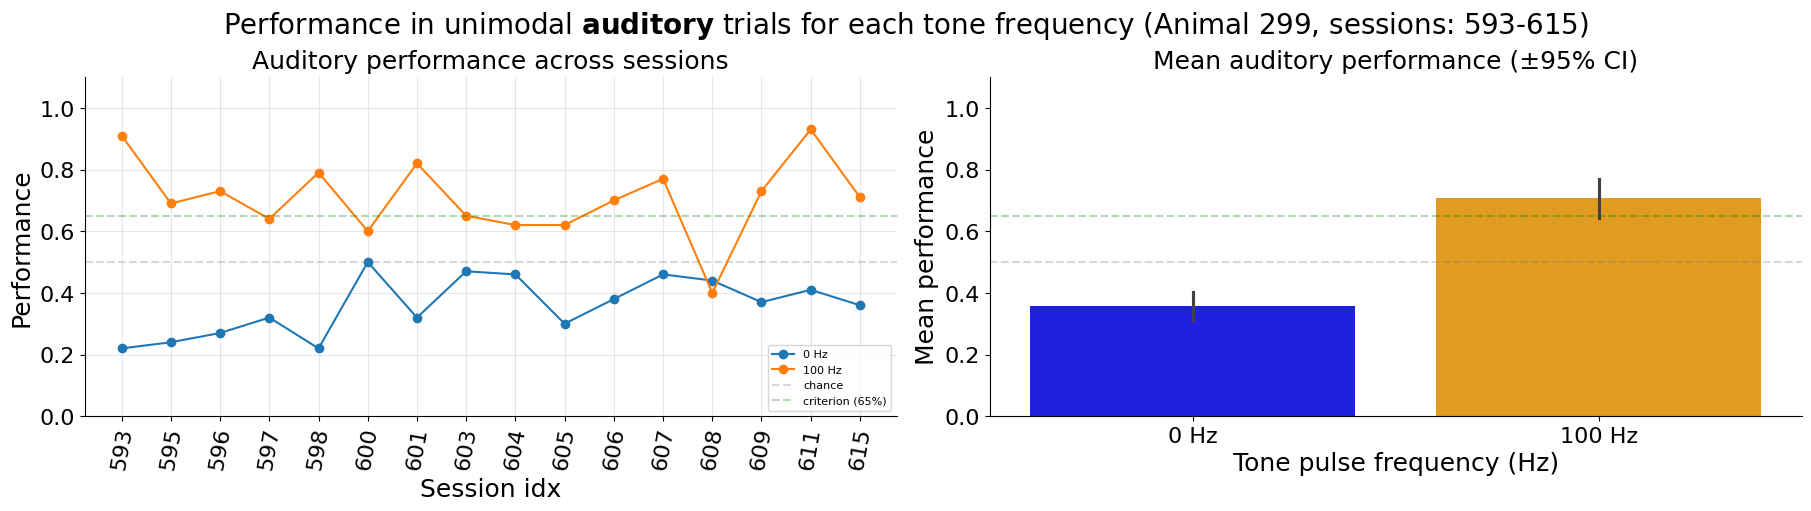

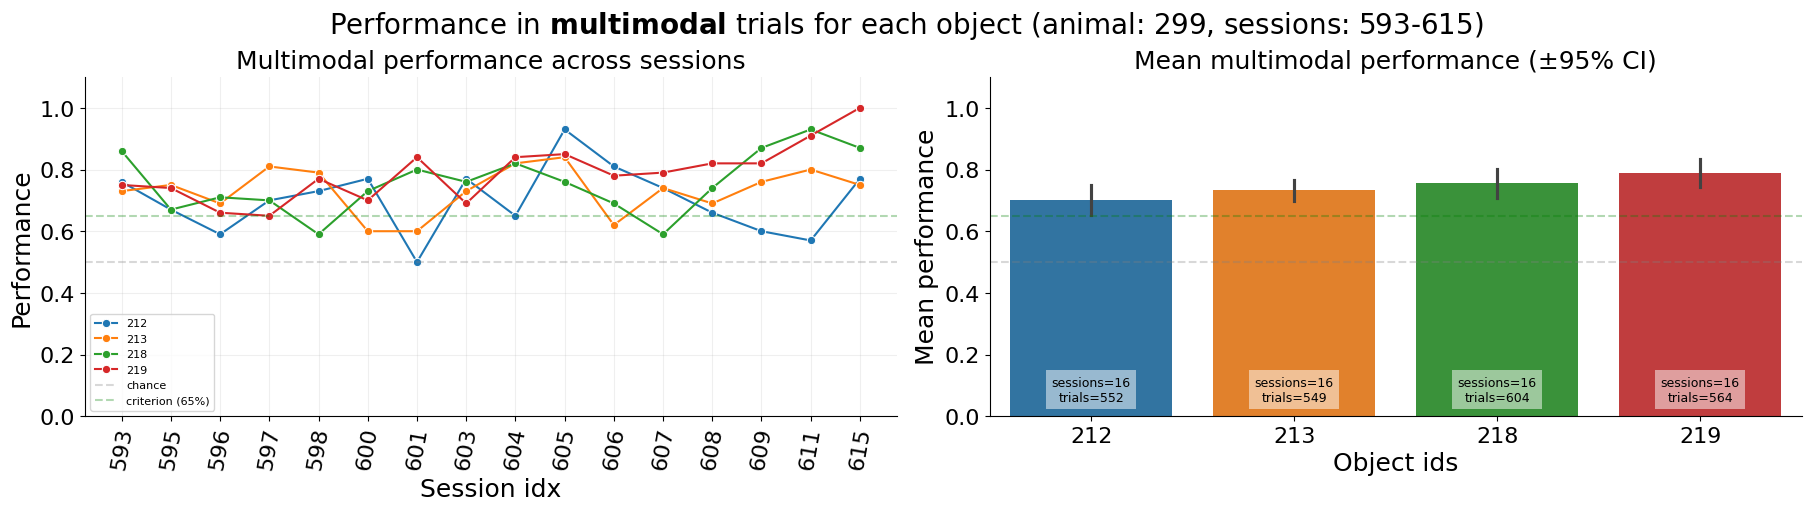

In [10]:
# Print per-object DataFrames summarizing number of session trials, valid per object trials,
# percentage per object in the session, object performance, rewarded/punished/aborted trials
# Performace in unimodal visual trials:
# get_visual_performance_summary(key) 
# Performance in unimodal auditory trials: 
# parameters: key (dict), pulse_freq ('all', '0', '100')
# get_auditory_performance_summary(key)
# Performace in multimodal trials:
# get_multimodal_performance_summary(key) 

# Line and bar plot of unimodal-visual and multimodal performance across sessions per object. 
# Parameters: key (dict), criterion (float), 
# default criterion: 0.65
plot_visual_performance_per_object(key)
plot_auditory_performance_per_object(key)
plot_multimodal_performance_per_object(key)

In [9]:
## Rename _statestatus ==> trials
## add bar plot